Please write your main code in this ipynb file. 

In [1]:
# import everything here
import pandas_datareader.data as web
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy.linalg import solve_banded
from scipy.stats.mstats import winsorize
from scipy.optimize import curve_fit
import seaborn as sns


c:\Users\sungw\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\sungw\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


## Part 1: Construct the Yield Curve 

### 1. Import dicrete treasury data from the Federal Reserve Economic Data (FRED) database.

In [2]:
def get_treasury_yields_from_fred():
    # Define the duration (in years) and the corresponding FRED ID for each treasury yield
    yield_map = {
        1/12: "DGS1MO",
        3/12: "DGS3MO",
        6/12: "DGS6MO",
        1: "DGS1",
        2: "DGS2",
        3: "DGS3",
        5: "DGS5",
        7: "DGS7",
        10: "DGS10",
        20: "DGS20",
        30: "DGS30"
    }
    
    series_ids = list(yield_map.values())
    
    try:
        # Obtain the data for the last 5 days (make sure to get the latest and valid working day data)
        start = datetime(2026, 4, 1)
        df = web.DataReader(series_ids, 'fred', start)
        
        # Take the last non-empty row of data
        latest_data = df.dropna().iloc[-1]
        
        # Convert to DataFrame
        results = pd.DataFrame({
            'Maturity': yield_map.keys(),
            'Yield': latest_data.values
        }).sort_values('Maturity')
        
        return results
        
    except Exception as e:
        print(f"Failed to retrieve data: {e}")
        return None

# Execute retrieval
treasury_data = get_treasury_yields_from_fred()
print(treasury_data)

     Maturity  Yield
0    0.083333   3.69
1    0.250000   3.69
2    0.500000   3.71
3    1.000000   3.67
4    2.000000   3.78
5    3.000000   3.80
6    5.000000   3.92
7    7.000000   4.10
8   10.000000   4.31
9   20.000000   4.88
10  30.000000   4.91


### 2. Build the yield curve class with interpolation methods(piece wise and cubic spline), including the improved area-preserving quadratic spline (APQS) method.

In [3]:
class YieldCurve:
    def __init__(self, maturities, yields):
        idx = np.argsort(maturities)
        self.T = np.array(maturities)[idx]
        self.y = np.array(yields)[idx]
        self.m = len(self.T)
        
        # Step 1: yields -> discount factors
        self.df = np.exp(-self.y * self.T)
        
        # Step 2: discount factors -> piecewise constant forward rates
        # P(T_j) = exp(-integral_0^{T_j} f(t)dt)
        # For interval [T_{j-1}, T_j]: A[j] = -log(P(T_j)/P(T_{j-1})) / (T_j - T_{j-1})
        T_aug = np.insert(self.T, 0, 0.0)
        df_aug = np.insert(self.df, 0, 1.0)  # P(0) = 1
        delta = np.diff(T_aug)
        
        self.T_aug = T_aug
        self.delta = delta
        # A[j] = piecewise constant forward for interval j (0-indexed)
        self.A = -np.log(df_aug[1:] / df_aug[:-1]) / delta

    def get_interpolation(self, method='apqs'):
        if method == 'piecewise':
            # Return yield curve (convert forward back to yield for display)
            def pw_yield(t):
                t = np.atleast_1d(np.asarray(t, dtype=float))
                # Find which interval
                idx = np.searchsorted(self.T, t, side='left')
                idx = np.clip(idx, 0, self.m - 1)
                return self.y[idx]
            return pw_yield
        
        elif method == 'cubic':
            from scipy.interpolate import CubicSpline
            return CubicSpline(self.T, self.y, bc_type='natural')
        
        elif method == 'apqs':
            return self._build_apq_spline()

    def _build_apq_spline(self):
        T_aug = self.T_aug
        delta = self.delta
        A = self.A   # piecewise constant FORWARD rates, NOT yields
        n = self.m + 1

        ab = np.zeros((3, n))
        ab[1, :] = 1.0

        denom = delta[:-1] + delta[1:]
        w_lower = 0.5 * delta[1:] / denom
        w_upper = 0.5 * delta[:-1] / denom

        ab[2, 1:-1] = w_lower
        ab[0, 1:-1] = w_upper
        ab[0, 0] = 0.5
        ab[2, -1] = 0.5

        rhs = np.zeros(n)
        rhs[0] = 1.5 * A[0]
        rhs[-1] = 1.5 * A[-1]
        rhs[1:-1] = 1.5 * (delta[1:] * A[:-1] + delta[:-1] * A[1:]) / denom

        f_nodes = solve_banded((1, 1), ab, rhs)

        def forward_func(t):
            """Returns instantaneous forward rate f(t)"""
            t = np.atleast_1d(np.asarray(t, dtype=float))
            res = np.empty_like(t, dtype=float)

            left_mask  = t <= T_aug[0]
            right_mask = t >= T_aug[-1]
            mid_mask   = ~(left_mask | right_mask)

            res[left_mask]  = f_nodes[0]
            res[right_mask] = f_nodes[-1]

            j = np.searchsorted(T_aug[1:], t[mid_mask], side='left')
            j = np.clip(j, 0, self.m - 1)
            t_mid = t[mid_mask]
            xi = (t_mid - T_aug[j]) / delta[j]

            f0 = f_nodes[j]
            f1 = f_nodes[j + 1]
            aj = A[j]
            res[mid_mask] = (f0*(1-xi) + f1*xi
                             - 3*(f0 + f1 - 2*aj)*xi*(1-xi))
            return res

        def yield_func(t):
            """
            Convert forward rate back to yield for display:
            y(T) = (1/T) * integral_0^T f(s) ds
            Computed numerically per query point.
            """
            t = np.atleast_1d(np.asarray(t, dtype=float))
            res = np.empty_like(t, dtype=float)
            
            for i, ti in enumerate(t):
                if ti <= 0:
                    res[i] = f_nodes[0]
                else:
                    # Integrate f from 0 to ti using fine grid
                    s = np.linspace(0, ti, max(200, int(ti * 50)))
                    f_vals = forward_func(s)
                    res[i] = np.trapz(f_vals, s) / ti
            return res
        
        # Save the forward_func for use in get_forward_rate
        self._apqs_forward_func = forward_func
        return yield_func
    
    def get_forward_rate(self, t, method='apqs'):
        t = np.atleast_1d(np.asarray(t, dtype=float))

        if method == 'apqs':
            if not hasattr(self, '_apqs_forward_func'):
                self._build_apq_spline()
            return self._apqs_forward_func(t)

        elif method == 'cubic':
            cs = CubicSpline(self.T, self.y, bc_type='natural')
            return np.where(t <= 0, cs(0), cs(t) + t * cs(t, 1))

        elif method == 'piecewise':
            j = np.searchsorted(self.T_aug[1:], t, side='left')
            j = np.clip(j, 0, self.m - 1)
            return self.A[j]

        else:
            raise ValueError(f"Unknown method '{method}'. Choose from: 'apqs', 'cubic', 'piecewise'")


    def get_discount_factor(self, t, method='apqs'):
        """
        P(0,t) = exp(-∫_0^t f(s)ds)
        
        For piecewise, use the analytical formula (with no numerical errors and no need for loops)
        For apqs/cubic, use vectorized cumulative trapezoid
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))

        if method == 'piecewise':
            # log P(0,t) = -sum_{j<j_end} A[j]*delta[j]  -  A[j_end]*(t - T_aug[j_end])
            #
            # First, calculate the cumulative log P value at each node for each interval.
            log_P_nodes = np.zeros(self.m + 1)
            log_P_nodes[1:] = -np.cumsum(self.A * self.delta)  # shape (m,)
            
            j = np.searchsorted(self.T_aug[1:], t, side='left')
            j = np.clip(j, 0, self.m - 1)
            
            # piecewise constant forward: log P(0,t) = log P at last node - A[j]*(t - T_aug[j])
            log_P = log_P_nodes[j] - self.A[j] * (t - self.T_aug[j])
            log_P[t <= 0] = 0.0
            return np.exp(log_P)

        else:
            # apqs / cubic: Calculate the integrals of all t values at once on the public fine grid.
            # Use cumulative trapezoid to avoid integrating each t separately
            t_max = np.max(t)
            n_grid = max(2000, int(t_max * 100))
            s = np.linspace(0, t_max, n_grid)          # public fine grid
            f_vals = self.get_forward_rate(s, method=method)
            
            # cumulative integral F(s) = ∫_0^s f(u)du
            from scipy.integrate import cumulative_trapezoid
            F = np.zeros(n_grid)
            F[1:] = cumulative_trapezoid(f_vals, s)    # shape (n_grid,)
            
            # For each query point t, interpolate F(t)
            F_interp = np.interp(t, s, F)
            result = np.exp(-F_interp)
            result[t <= 0] = 1.0
            return result


    def get_zero_rate(self, t, method='apqs'):
        """
        y(t) = -log(P(0,t)) / t
        use get_discount_factor
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))
        P = self.get_discount_factor(t, method=method)
        
        result = np.empty_like(t, dtype=float)
        nonzero = t > 0
        result[nonzero] = -np.log(P[nonzero]) / t[nonzero]
        result[~nonzero] = self.get_forward_rate(np.array([1e-8]), method=method)[0]
        return result

### 3. Visualization of the curves with different interpolation methods(piece wise and cubic spline, area-preserving quadratic spline (APQS) method).

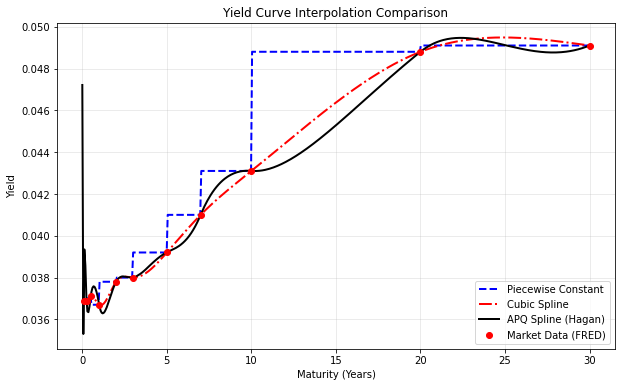

In [4]:
# Prepare Data (Assumes treasury_data from previous step)
# Convert yield to decimal for calculation (e.g., 4.5% -> 0.045)
maturities = treasury_data['Maturity'].values
yields = treasury_data['Yield'].values / 100.0

# Instantiate and Generate Curves
curve_builder = YieldCurve(maturities, yields)
t_range = np.linspace(0, 30, 500)

methods = {
    'Piecewise Constant': ('piecewise', 'blue', '--'),
    'Cubic Spline': ('cubic', 'red', '-.'),
    'APQ Spline (Hagan)': ('apqs', 'black', '-')
}

plt.figure(figsize=(10, 6))
plt.scatter(maturities, yields, color='red', label='Market Data (FRED)', zorder=5)

for label, (m, color, style) in methods.items():
    f_interp = curve_builder.get_interpolation(method=m)
    plt.plot(t_range, f_interp(t_range), label=label, color=color, linestyle=style, lw=2)

plt.title("Yield Curve Interpolation Comparison")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 2 Calibrate and Simulate Interest Rate Paths

### 1. Interface from Part 1

We pass the APQS yield curve from Part 1 into the interest-rate simulation module. The `YieldCurve` object provides three key inputs for the Hull-White setup:

1. the initial instantaneous forward curve,
2. the initial short rate,
3. the discount factor curve.

The 2-factor Hull-White model is written as

$$
r(t)=x(t)+y(t)+\phi(t),
$$

where $x(t)$ and $y(t)$ are stochastic mean-reverting factors, and $\phi(t)$ is the deterministic shift term. The role of $\phi(t)$ is to anchor the short-rate model to the observed initial Treasury term structure.

The instantaneous forward curve is

$$
f(0,t).
$$

This curve is extracted from the APQS curve and used to construct $\phi(t)$.

The initial short rate is approximated by the near-zero maturity forward rate:

$$
r(0) \approx f(0,0).
$$

The discount factor curve is computed from the forward curve as

$$
P(0,T)=\exp\left(-\int_0^T f(0,u)\,du\right).
$$

In a full market calibration, discount factors would also be used together with caplet or swaption prices to calibrate volatility and mean-reversion parameters. In this project, we use the APQS curve to make the Hull-White simulation curve-consistent, while the stochastic parameters are chosen as representative values for the Monte Carlo pipeline.

### 1. Interface from Part 1

In [19]:
maturities = treasury_data["Maturity"].values
yields = treasury_data["Yield"].values / 100

curve = YieldCurve(maturities, yields)
method = "apqs"  #alternatives: 'cubic', 'piecewise'

t_curve = np.linspace(0.001, 30, 500)
f0t = curve.get_forward_rate(t_curve, method=method)
P0T = curve.get_discount_factor(t_curve, method=method)
r0 = curve.get_forward_rate(np.array([1e-6]), method=method)[0]

print("Initial short rate r(0):", r0)
print("Example forward rate f(0,5):", curve.get_forward_rate(np.array([5]), method=method)[0])
print("Example discount factor P(0,10):", curve.get_discount_factor(np.array([10]), method=method)[0])


Initial short rate r(0): 0.04721062158738635
Example forward rate f(0,5): 0.041166213527239516
Example discount factor P(0,10): 0.6498583655391915


### 2. 2-Factor Hull-White Model
We model the short rate using a 2-factor Hull-White specification:

$$
r(t)=x(t)+y(t)+\phi(t),
$$

where the two stochastic factors follow mean-reverting Gaussian dynamics:

$$
dx_t=-a x_t\,dt+\sigma\,dW_{1,t},
$$

$$
dy_t=-b y_t\,dt+\eta\,dW_{2,t},
$$

with correlation

$$
dW_{1,t}dW_{2,t}=\rho\,dt.
$$

The deterministic shift term $\phi(t)$ is computed from the initial forward curve. This is the part that makes the model consistent with the observed Treasury term structure from Part 1.

In [20]:
#Model specification:
# r(t) = x(t) + y(t) + phi(t)
# dx(t) = -a x(t) dt + sigma dW1(t)
# dy(t) = -b y(t) dt + eta dw2(t)
# corr(dW1, dW2) = rho

class HullWhiteModel:
    def __init__(self, yield_curve, a: float, b: float, sigma: float, eta: float, rho: float, method: str = 'apqs'):
        """
        yield_curve: YieldCurve object from Part 1
        Initialize the 2-factor Hull-White model with the given yield curve,
        mean reversion speeds a and b, volatilities sigma and eta,
        correlation rho, and interpolation method.
        """
        self.curve = yield_curve
        self.a = a
        self.b = b
        self.sigma = sigma
        self.eta = eta
        self.rho = rho
        self.method = method


    def f0(self, t):
        """
        Initial instantaneous forward rate f(0,t) from yield curve
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))
        return self.curve.get_forward_rate(t, method=self.method)

    def phi(self, t):
        """
        Deterministic shift phi(t)

        phi(t) = f(0,t)
                 + (sigma^2 / (2a^2)) * (1 - e^{-at})^2
                 + (eta^2   / (2b^2)) * (1 - e^{-bt})^2
                 + (rho*sigma*eta/(ab)) * (1 - e^{-at})(1 - e^{-bt})
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))
        
        term1 = (self.sigma ** 2 / (2 * self.a ** 2)) * (1 - np.exp(-self.a * t)) ** 2
        term2 = (self.eta ** 2   / (2 * self.b ** 2)) * (1 - np.exp(-self.b * t)) ** 2
        term3 = (self.rho * self.sigma * self.eta / (self.a * self.b)) \
                * (1 - np.exp(-self.a * t)) * (1 - np.exp(-self.b * t))

        return self.f0(t) + term1 + term2 + term3


    def simulate(self, T: float, n_steps: int, n_paths: int, seed: int = None):
        """
        Simulate the two latent factors x(t), y(t), then construct
            r(t) = x(t) + y(t) +phi(t) 
        using Euler.
        """
        if seed is not None:
            np.random.seed(seed)
        
        dt = T / n_steps
        sqrt_dt = np.sqrt(dt)
        t_grid = np.linspace(0, T, n_steps + 1)

        x_paths = np.zeros((n_paths, n_steps + 1))
        y_paths = np.zeros((n_paths, n_steps + 1))
        rates = np.zeros((n_paths, n_steps + 1))

        #Correlated Brownian shocks
        z1 = np.random.normal(size=(n_paths, n_steps))
        z2_indep = np.random.normal(size=(n_paths, n_steps))
        z2 = self.rho * z1 + np.sqrt(1 - self.rho ** 2) * z2_indep

        phi_grid = self.phi(t_grid)

        #Initial short rate from the initial forward curve
        r0 = self.curve.get_forward_rate(np.array([1e-6]), method=self.method)[0]

        #Initial conditions
        x_paths[:, 0] = 0
        y_paths[:, 0] = 0
        rates[:, 0] = r0 


        for i in range(n_steps):
            x_paths[:, i + 1] = (x_paths[:, i] + (-self.a * x_paths[:, i]) * dt 
                                 + self.sigma * sqrt_dt * z1[:, i])

            y_paths[:, i + 1] = (y_paths[:, i] + (-self.b * y_paths[:, i]) * dt 
                                 + self.eta * sqrt_dt * z2[:, i])
            
            rates[:, i + 1] = x_paths[:, i + 1] + y_paths[:, i + 1] + phi_grid[i + 1]
         
        
        return rates, x_paths, y_paths, t_grid

### 3. Curve-Consistent Hull-White Setup

The deterministic shift term $\phi(t)$ is calibrated to the initial APQS forward curve, so the Hull-White simulation is anchored to the observed Treasury term structure.

The stochastic parameters $(a,b,\sigma,\eta,\rho)$ are chosen as representative values rather than fully calibrated to an interest-rate volatility surface. A full calibration would require additional market data such as caplet or swaption implied volatilities, which is outside the scope of this project.

Therefore, this section should be interpreted as a curve-consistent Hull-White simulation with representative stochastic dynamics.

In [33]:
# Representative parameters

a = 0.5        # faster mean reversion factor
b = 0.08       # slower mean reversion factor
sigma = 0.015  # volatility
eta = 0.008    # volatility
rho = -0.7     #correlation between factor shocks

hw = HullWhiteModel(curve, a=a, b=b, sigma=sigma, eta=eta, rho=rho, method=method)

### 4. Simulate Short-Rate Paths

Using the curve-consistent Hull-White model, we simulate short-rate paths over a 30-year horizon. These simulated paths are the main interest-rate scenarios used later in Part 3 to generate refinancing incentives and in Part 4 to discount MBS cash flows.

The main output is `rates`, with shape

$$
(\text{number of paths}, \text{number of time steps}+1).
$$

This `rates` object should remain the primary rate input for the CPR model and MBS valuation.

In [22]:
T_sim = 30
n_steps = 500
n_paths = 1000

rates, x_paths, y_paths, t_grid = hw.simulate(T=T_sim, n_steps=n_steps, n_paths=n_paths, seed=42)

print("rates shape:", rates.shape)
print("x_paths shape:", x_paths.shape)
print("y_paths shape:", y_paths.shape)
print("t_grid shape:", t_grid.shape)

rates shape: (1000, 501)
x_paths shape: (1000, 501)
y_paths shape: (1000, 501)
t_grid shape: (501,)


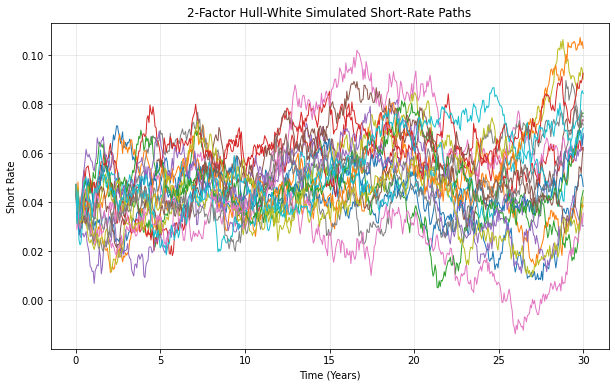

In [23]:
# Plot simulated short-rate paths

plt.figure(figsize=(10, 6))
for i in range(20):
    plt.plot(t_grid, rates[i], lw=1)

plt.title("2-Factor Hull-White Simulated Short-Rate Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.grid(True, alpha=0.3)
plt.show()

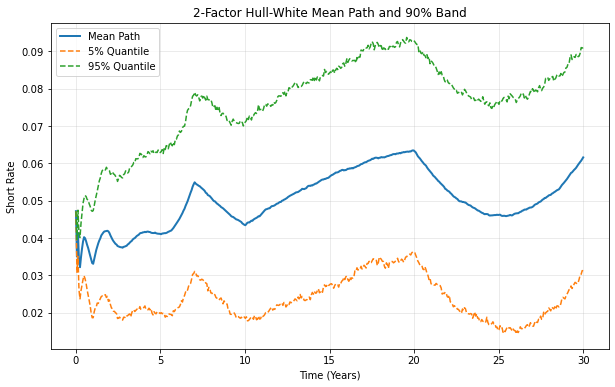

In [24]:
mean_path = rates.mean(axis=0)
q05 = np.quantile(rates, 0.05, axis=0)
q95 = np.quantile(rates, 0.95, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(t_grid, mean_path, label="Mean Path", lw=2)
plt.plot(t_grid, q05, linestyle="--", label="5% Quantile")
plt.plot(t_grid, q95, linestyle="--", label="95% Quantile")
plt.title("2-Factor Hull-White Mean Path and 90% Band")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
n_paths, n_times = rates.shape

short_rate_df = pd.DataFrame({"path_id": np.repeat(np.arange(n_paths), n_times),
                              "time_years": np.tile(t_grid, n_paths),
                              "month": np.tile(np.round(t_grid * 12).astype(int), n_paths),
                              "short_rate": rates.reshape(-1)})

short_rate_df

,path_id,time_years,month,short_rate
0,0,0.00,0,0.047211
1,0,0.06,1,0.034582
2,0,0.12,1,0.039481
3,0,0.18,2,0.034413
4,0,0.24,3,0.036848
...,...,...,...,...
500995,999,29.76,357,0.067773
500996,999,29.82,358,0.068374
500997,999,29.88,359,0.068368
500998,999,29.94,359,0.069318


### 5. Benchmark Model: Vasicek Short-Rate Simulation

As a benchmark, we also simulate a one-factor Vasicek model using the same initial short rate, simulation horizon, number of time steps, and number of Monte Carlo paths as the Hull-White model.

The Vasicek model is

$$
dr_t=\kappa(\theta-r_t)\,dt+\sigma_v\,dW_t.
$$

This model is useful for visualizing simple mean-reverting short-rate behavior. However, unlike the Hull-White model, Vasicek does not fit the full initial term structure. It only starts from the initial short rate $r(0)$ and then mean-reverts toward a constant long-run mean $\theta$.

Therefore, Vasicek is included only as a benchmark visualization. The main rate engine for Part 3 and Part 4 remains the 2-factor Hull-White model.

In [26]:
# ============================================================
# Benchmark Model: Vasicek Short-Rate Simulation
# ============================================================

class VasicekModel:
    def __init__(self, r0: float, kappa: float, theta: float, sigma: float):
        """
        Vasicek short-rate model:

            dr_t = kappa * (theta - r_t) dt + sigma dW_t

        r0    : initial short rate
        kappa : mean reversion speed
        theta : long-run mean rate
        sigma : short-rate volatility
        """
        self.r0 = r0
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma

    def simulate(self, T: float, n_steps: int, n_paths: int, seed: int = None):
        """
        Simulate Vasicek short-rate paths using Euler discretization.

        Returns:
            rates_vasicek : shape (n_paths, n_steps + 1)
            t_grid        : shape (n_steps + 1,)
        """
        if seed is not None:
            np.random.seed(seed)

        dt = T / n_steps
        sqrt_dt = np.sqrt(dt)
        t_grid = np.linspace(0, T, n_steps + 1)

        rates = np.zeros((n_paths, n_steps + 1))
        rates[:, 0] = self.r0

        z = np.random.normal(size=(n_paths, n_steps))

        for i in range(n_steps):
            rates[:, i + 1] = (
                rates[:, i]
                + self.kappa * (self.theta - rates[:, i]) * dt
                + self.sigma * sqrt_dt * z[:, i]
            )

        return rates, t_grid

In [27]:
# Initial short rate from Part 1 / APQS curve
r0_vasicek = r0

# Representative Vasicek parameters
kappa_v = 0.25       # mean reversion speed
theta_v = 0.04       # long-run mean rate, around 4%
sigma_v = 0.015      # volatility, similar scale to HW sigma

vasicek = VasicekModel(
    r0=r0_vasicek,
    kappa=kappa_v,
    theta=theta_v,
    sigma=sigma_v
)

rates_vasicek, t_grid_vasicek = vasicek.simulate(
    T=T_sim,
    n_steps=n_steps,
    n_paths=n_paths,
    seed=42
)

print("Vasicek rates shape:", rates_vasicek.shape)
print("Vasicek t_grid shape:", t_grid_vasicek.shape)

Vasicek rates shape: (1000, 501)
Vasicek t_grid shape: (501,)


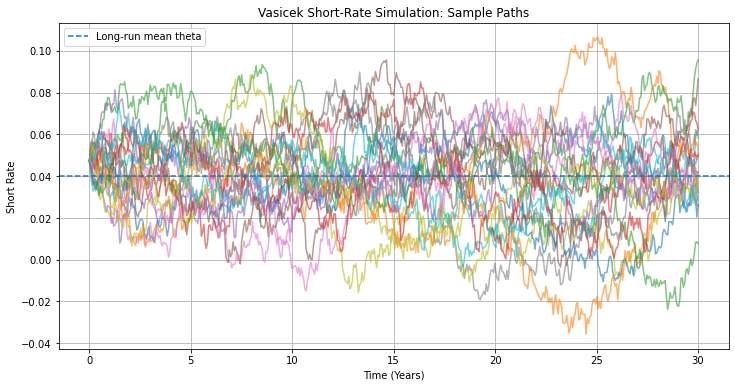

In [28]:
plt.figure(figsize=(12, 6))

for i in range(20):
    plt.plot(t_grid_vasicek, rates_vasicek[i, :], alpha=0.6)

plt.axhline(theta_v, linestyle="--", label="Long-run mean theta")
plt.title("Vasicek Short-Rate Simulation: Sample Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.legend()
plt.grid(True)
plt.show()

### 6. Visualization: Hull-White vs Vasicek

The plots below compare the curve-consistent 2-factor Hull-White simulation with the simpler Vasicek benchmark.

The Hull-White mean path should closely follow the initial forward curve because the deterministic shift term $\phi(t)$ is constructed from $f(0,t)$. By contrast, the Vasicek mean path reverts toward its constant long-run mean $\theta$, so it does not reproduce the full initial yield-curve shape.

This comparison supports our use of Hull-White as the main interest-rate model for the MBS valuation pipeline, while Vasicek is retained only as a simple benchmark.

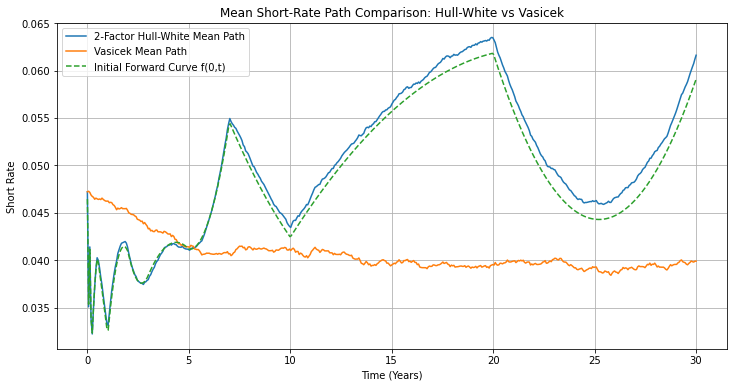

In [29]:
hw_mean = rates.mean(axis=0)
vasicek_mean = rates_vasicek.mean(axis=0)

plt.figure(figsize=(12, 6))

plt.plot(t_grid, hw_mean, label="2-Factor Hull-White Mean Path")
plt.plot(t_grid_vasicek, vasicek_mean, label="Vasicek Mean Path")
plt.plot(t_curve, f0t, linestyle="--", label="Initial Forward Curve f(0,t)")

plt.title("Mean Short-Rate Path Comparison: Hull-White vs Vasicek")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.legend()
plt.grid(True)
plt.show()

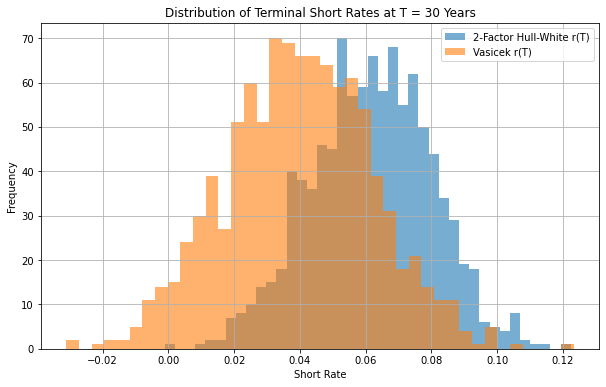

In [30]:
plt.figure(figsize=(10, 6))

plt.hist(rates[:, -1], bins=40, alpha=0.6, label="2-Factor Hull-White r(T)")
plt.hist(rates_vasicek[:, -1], bins=40, alpha=0.6, label="Vasicek r(T)")

plt.title("Distribution of Terminal Short Rates at T = 30 Years")
plt.xlabel("Short Rate")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
summary_df = pd.DataFrame({
    "Model": ["2-Factor Hull-White", "Vasicek"],
    "Mean r(T)": [rates[:, -1].mean(), rates_vasicek[:, -1].mean()],
    "Std r(T)": [rates[:, -1].std(), rates_vasicek[:, -1].std()],
    "Min r(T)": [rates[:, -1].min(), rates_vasicek[:, -1].min()],
    "Max r(T)": [rates[:, -1].max(), rates_vasicek[:, -1].max()]
})

summary_df

,Model,Mean r(T),Std r(T),Min r(T),Max r(T)
0,2-Factor Hull-White,0.061611,0.018394,-0.001087,0.122362
1,Vasicek,0.039896,0.022157,-0.031026,0.123241


### Part 3 Model Nonlinear Prepayment Behavior under changing interest rate conditions

### 1. Data Loading & CPR Calculation

In [34]:
# Load data
df = pd.read_excel('FRE_DPR_Cumulative.xlsx')

# Compute SMM and CPR from raw data
df['SMM_calc'] = df['Unscheduled Principal Reduction Amount'] / df['Cohort Current UPB']
df['CPR_calc'] = 1 - (1 - df['SMM_calc'])**12

# Winsorize bottom 20% and filter out near-zero prepayments
df['CPR_calc'] = winsorize(df['CPR_calc'], limits=[0.20, 0])
df = df[df['CPR_calc'] >= 0.02].copy()

# Compute refinancing incentive: I = WA coupon rate - benchmark rate (4.5%)
df['refinancing incentive_calc'] = (df['Cohort WA Current Interest Rate'] / 100) - 0.045

print(f"Rows after filtering: {len(df)}")
print(f"CPR_calc mean: {df['CPR_calc'].mean():.4f}")
print(f"Refinancing incentive mean: {df['refinancing incentive_calc'].mean():.4f}")

ImportError: Pandas requires version '3.1.0' or newer of 'openpyxl' (version '3.0.9' currently installed).

### 2. Logistic CPR Model Calibration

cpr_min_hat (high prepayment) = 0.0307
cpr_max_hat (low prepayment)  = 0.0270


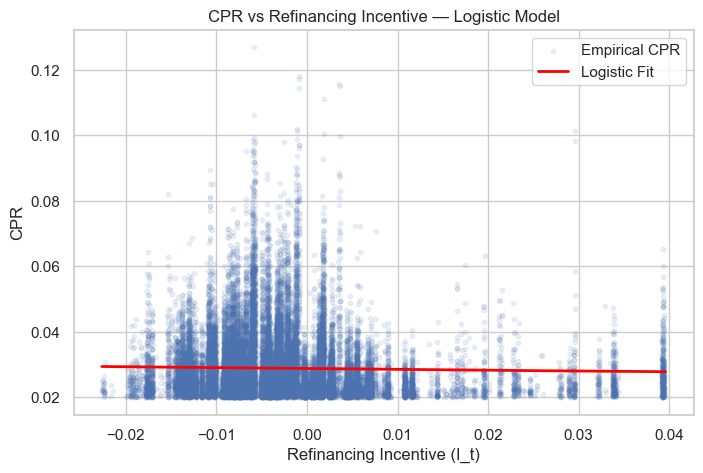

In [ ]:
# --- Model parameters ---
k_hat    = 30    # steepness of logistic curve (from curve_fit convention)
theta_hat = 0.0  # midpoint incentive

def logistic_cpr(I, cpr_min, cpr_max):
    return cpr_max + (cpr_min - cpr_max) / (1 + np.exp(k_hat * (I - theta_hat)))

# Fit cpr_min and cpr_max to data
fit_df = df[['refinancing incentive_calc', 'CPR_calc']].dropna().copy()
x = fit_df['refinancing incentive_calc'].values
y = fit_df['CPR_calc'].values

low  = df[df['refinancing incentive_calc'] <  0.0]['CPR_calc']
high = df[df['refinancing incentive_calc'] > 0.02]['CPR_calc']

cpr_min_hat = low.mean()    
cpr_max_hat = high.mean()   

print(f"cpr_min_hat (high prepayment) = {cpr_min_hat:.4f}")
print(f"cpr_max_hat (low prepayment)  = {cpr_max_hat:.4f}")


df['CPR_model'] = logistic_cpr(df['refinancing incentive_calc'], cpr_min_hat, cpr_max_hat)
df['SMM_model'] = 1 - (1 - df['CPR_model'])**(1/12)
df['residual']  = df['CPR_calc'] - df['CPR_model']

# Visualize fit
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
plt.scatter(df['refinancing incentive_calc'], df['CPR_calc'],
            alpha=0.1, s=10, label='Empirical CPR')
I_range = np.linspace(df['refinancing incentive_calc'].min(),
                      df['refinancing incentive_calc'].max(), 300)
plt.plot(I_range, logistic_cpr(I_range, cpr_min_hat, cpr_max_hat),
         color='red', lw=2, label='Logistic Fit')
plt.xlabel('Refinancing Incentive (I_t)')
plt.ylabel('CPR')
plt.title('CPR vs Refinancing Incentive — Logistic Model')
plt.legend()
plt.show()

### 3. Bootstrap CPR Bounds & CPR Simulation Function

In [ ]:
def draw_cpr_bounds_from_cpr(df, lower_q=0.2, upper_q=0.8):
    """
    Bootstrap CPR_min and CPR_max from the empirical CPR distribution tails.
    """
    cpr = df['CPR_calc'].dropna().values
    low  = cpr[cpr <= np.quantile(cpr, lower_q)]
    high = cpr[cpr >= np.quantile(cpr, upper_q)]
    cpr_min_s = np.mean(np.random.choice(low,  size=len(low),  replace=True))
    cpr_max_s = np.mean(np.random.choice(high, size=len(high), replace=True))
    return min(cpr_min_s, cpr_max_s), max(cpr_min_s, cpr_max_s)


def simulate_cpr_path(I_path, df):
    """
    Simulate a CPR path given a refinancing incentive path I_path.
    Uses bootstrapped bounds + fitted logistic + empirical residual noise.
    """
    cpr_min_s, cpr_max_s = draw_cpr_bounds_from_cpr(df)
    cpr_mean = cpr_min_s + (cpr_max_s - cpr_min_s) / (
        1 + np.exp(-k_hat * (I_path - theta_hat))
    )
    residuals = df['residual'].dropna().values 
    eps = np.random.choice(residuals, size=len(I_path), replace=True)
    return np.clip(cpr_mean + eps, 0, 1)


# Validate bootstrap distribution (1000 draws)
mins, maxs = [], []
for _ in range(1000):
    lo, hi = draw_cpr_bounds_from_cpr(df)
    mins.append(lo); maxs.append(hi)
mins, maxs = np.array(mins), np.array(maxs)

print(f"CPR_min  mean={mins.mean():.4f}  std={mins.std():.4f}  5/95={np.percentile(mins,[5,95])}")
print(f"CPR_max  mean={maxs.mean():.4f}  std={maxs.std():.4f}  5/95={np.percentile(maxs,[5,95])}")

# Use mean bounds as point estimates for Part 4
cpr_min = mins.mean()
cpr_max = maxs.mean()

CPR_min  mean=0.0210  std=0.0000  5/95=[0.02096247 0.02098902]
CPR_max  mean=0.0463  std=0.0002  5/95=[0.04607233 0.04657765]


### 4. Coupon Rate Extraction & Refi Incentive Projection

Coupon rates: [0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05  0.055 0.06  0.065 0.07
 0.075]


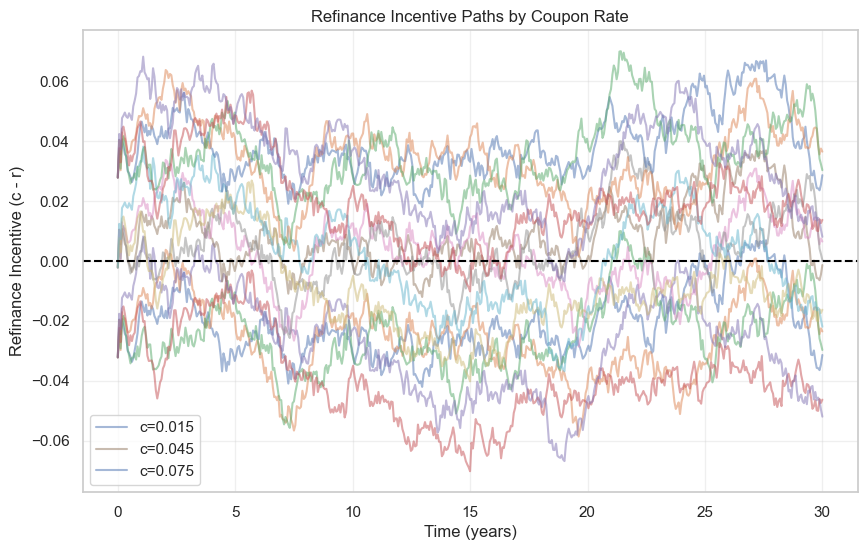

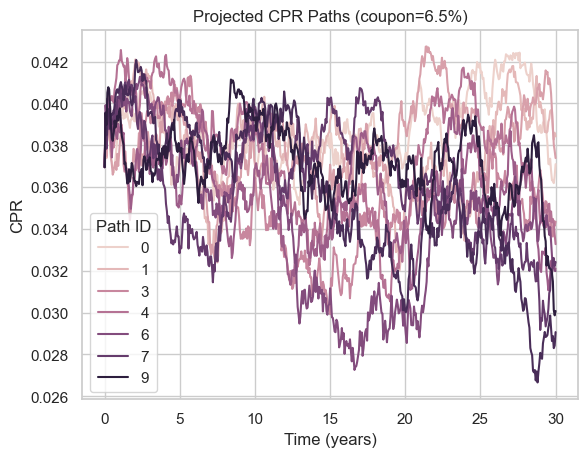

In [ ]:
# Clean WA Net Interest Rate column
df['cleaned_WA Net Interest Rate'] = (
    df['WA Net Interest Rate'].astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float) / 100
)

# Unique coupon rates
coupon_list = np.sort(df['cleaned_WA Net Interest Rate'].dropna().unique())
coupon_df   = pd.DataFrame({'coupon_rate': coupon_list})
print("Coupon rates:", coupon_list)

# Cross join with short_rate_df from Part 2 and compute refi incentive
refi_df = coupon_df.merge(short_rate_df, how='cross')
refi_df['refi_incentive'] = refi_df['coupon_rate'] - refi_df['short_rate']
refi_df['CPR_proj'] = cpr_min + (cpr_max - cpr_min) / (
    1 + np.exp(-k_hat * (refi_df['refi_incentive'] - theta_hat))
)
refi_df = refi_df.sort_values(['coupon_rate', 'path_id', 'time_years']).reset_index(drop=True)

# Visualization: Refi incentive paths for 3 sample coupons
sample_coupons = coupon_list[[0, len(coupon_list)//2, -1]]
plt.figure(figsize=(10, 6))
for c in sample_coupons:
    subset = refi_df[(refi_df['coupon_rate'] == c) & (refi_df['path_id'] < 5)]
    for pid in subset['path_id'].unique():
        path = subset[subset['path_id'] == pid]
        plt.plot(path['time_years'], path['refi_incentive'],
                 alpha=0.5, label=f'c={c:.3f}' if pid == 0 else "")
plt.axhline(0, linestyle='--', color='black')
plt.xlabel('Time (years)')
plt.ylabel('Refinance Incentive (c - r)')
plt.title('Refinance Incentive Paths by Coupon Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Visualization: Projected CPR paths for coupon=0.065
sns.set(style="whitegrid")
sample_multi = refi_df[
    (refi_df['coupon_rate'] == 0.065) &
    (refi_df['path_id'].isin(range(10)))
]
sns.lineplot(x='time_years', y='CPR_proj', hue='path_id', data=sample_multi)
plt.title('Projected CPR Paths (coupon=6.5%)')
plt.xlabel('Time (years)')
plt.ylabel('CPR')
plt.legend(title='Path ID')
plt.show()


## Part 4 MBS Valuation

In [16]:
def calculate_mbs_price(B0, coupon_rate, N, hw_rates, refi_df, method='apqs'):
    """
    B0          : Initial mortgage balance
    coupon_rate : MBS coupon rate (e.g. 0.06), used to select CPR paths from refi_df
    N           : Total number of months (e.g. 360)
    hw_rates    : Simulated short rate paths (M x N+1 matrix)
    refi_df     : DataFrame with columns [coupon_rate, path_id, month, CPR_proj]
    method      : Yield curve interpolation method (for reference)
    """
    # Select the CPR paths corresponding to the given coupon_rate
    cpr_subset = refi_df[refi_df['coupon_rate'] == coupon_rate]
    cpr_sim = cpr_subset.pivot_table(
        index='path_id', columns='month', values='CPR_proj', aggfunc='mean'
    ).values  # shape: (M, N+1)

    M = hw_rates.shape[0]
    q = coupon_rate / 12  # Monthly mortgage rate，coupon_rate
    
    pmt = B0 * (q * (1 + q)**N) / ((1 + q)**N - 1)
    
    pv_all_paths = np.zeros(M)
    tolerance = 1e-6
    
    for m in range(M):
        balance = B0
        cf_path = np.zeros(N)
        discount_factor = 1.0
        
        for t in range(N):
            if balance <= tolerance:
                break
            
            interest = balance * q
            sched_principal = min(pmt - interest, balance)
            remaining = balance - sched_principal
            
            smm = 1 - (1 - cpr_sim[m, t])**(1/12)
            prepay = min(smm * remaining, remaining)
            
            cf_path[t] = interest + sched_principal + prepay
            balance -= (sched_principal + prepay)
            
            discount_factor *= np.exp(-hw_rates[m, t] * (1/12))
            cf_path[t] *= discount_factor
            
        pv_all_paths[m] = np.sum(cf_path)
    
    mbs_price = np.mean(pv_all_paths)
    return mbs_price, pv_all_paths

In [17]:
def run_mbs_valuation(method='apqs', B0=1.0, coupon_rate=0.06, N=361, seed=42,n_paths=300):
    
    T_sim = N / 12
    n_steps = N
    
    curve = YieldCurve(maturities, yields)
    hw = HullWhiteModel(curve, a=a, b=b, sigma=sigma, eta=eta, rho=rho, method=method)
    rates, x_paths, y_paths, t_grid = hw.simulate(
        T=T_sim, n_steps=n_steps, n_paths=n_paths, seed=seed
    )
    
    n_paths_sim, n_times = rates.shape
    short_rate_df = pd.DataFrame({
        "path_id": np.repeat(np.arange(n_paths_sim), n_times),
        "time_years": np.tile(t_grid, n_paths_sim),
        "month": np.tile(np.round(t_grid * 12).astype(int), n_paths_sim),
        "short_rate": rates.reshape(-1)
    })
    
    refi_df = coupon_df.merge(short_rate_df, how='cross')
    refi_df['refi_incentive'] = refi_df['coupon_rate'] - refi_df['short_rate']
    refi_df['CPR_proj'] = cpr_min + (cpr_max - cpr_min) / (
        1 + np.exp(-k_hat * (refi_df['refi_incentive'] - theta_hat))
    )
    
    price, all_pvs = calculate_mbs_price(
        B0=B0,
        coupon_rate=coupon_rate,
        N=N,
        hw_rates=rates,
        refi_df=refi_df,
        method=method
    )
    
    print(f"Method      : {method}")
    print(f"Coupon Rate : {coupon_rate:.1%}")
    print(f"MBS Price   : {price:.4f}")
    return price, all_pvs

Method      : apqs
Coupon Rate : 6.0%
MBS Price   : 1.1230
Method      : apqs
Coupon Rate : 1.5%
MBS Price   : 0.7831
Method      : apqs
Coupon Rate : 2.0%
MBS Price   : 0.8219
Method      : apqs
Coupon Rate : 2.5%
MBS Price   : 0.8609
Method      : apqs
Coupon Rate : 3.0%
MBS Price   : 0.8999
Method      : apqs
Coupon Rate : 3.5%
MBS Price   : 0.9386
Method      : apqs
Coupon Rate : 4.0%
MBS Price   : 0.9769
Method      : apqs
Coupon Rate : 4.5%
MBS Price   : 1.0145
Method      : apqs
Coupon Rate : 5.0%
MBS Price   : 1.0515
Method      : apqs
Coupon Rate : 5.5%
MBS Price   : 1.0877
Method      : apqs
Coupon Rate : 6.0%
MBS Price   : 1.1230
Method      : apqs
Coupon Rate : 6.5%
MBS Price   : 1.1574
Method      : apqs
Coupon Rate : 7.0%
MBS Price   : 1.1908
Method      : apqs
Coupon Rate : 7.5%
MBS Price   : 1.2233


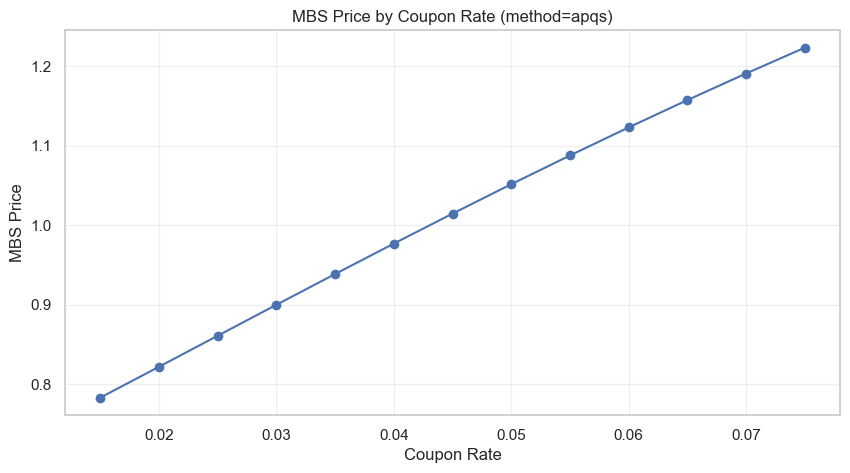

In [18]:
# single coupon
price, pvs = run_mbs_valuation(method='apqs', coupon_rate=0.06)

# multiple coupons
results = {}
for c in coupon_list:
    price, _ = run_mbs_valuation(method='apqs', coupon_rate=c)
    results[c] = price

# visualize price by coupon rate
plt.figure(figsize=(10, 5))
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xlabel('Coupon Rate')
plt.ylabel('MBS Price')
plt.title('MBS Price by Coupon Rate (method=apqs)')
plt.grid(True, alpha=0.3)
plt.show()


#testing different interest rate models

In [19]:
#Testing different interest rate models. 
methods = ['piecewise', 'cubic', 'apqs']
results = []
pv_dict = {}

for method in methods:
    price, pvs = run_mbs_valuation(
        method=method,
        B0=1.0,
        coupon_rate=0.025,
        N=360,
        seed=42,
        n_paths=50   # reduce trials here
    )

    pv_dict[method] = pvs

    results.append({
        'method': method,
        'price': price,
        'pv_mean': np.mean(pvs),
        'pv_std': np.std(pvs),
        'pv_p5': np.percentile(pvs, 5),
        'pv_p95': np.percentile(pvs, 95)
    })

results_df = pd.DataFrame(results)
results_df

Method      : piecewise
Coupon Rate : 2.5%
MBS Price   : 0.8597
Method      : cubic
Coupon Rate : 2.5%
MBS Price   : 0.8612
Method      : apqs
Coupon Rate : 2.5%
MBS Price   : 0.8627


,method,price,pv_mean,pv_std,pv_p5,pv_p95
0,piecewise,0.859729,0.859729,0.053194,0.773478,0.944107
1,cubic,0.861236,0.861236,0.053358,0.774700,0.945870
2,apqs,0.862708,0.862708,0.053650,0.775631,0.947758


Testing under different interest rate model

In [20]:
_, pvs_piecewise = run_mbs_valuation(
    method='piecewise',
    B0=1.0,
    coupon_rate=0.025,
    N=360,
    seed=42
)

_, pvs_cubic = run_mbs_valuation(
    method='cubic',
    B0=1.0,
    coupon_rate=0.025,
    N=360,
    seed=42
)

_, pvs_apq = run_mbs_valuation(
    method='apqs',
    B0=1.0,
    coupon_rate=0.025,
    N=360,
    seed=42
)

diff_cubic = pvs_cubic - pvs_piecewise
diff_apq   = pvs_apq   - pvs_piecewise

Method      : piecewise
Coupon Rate : 2.5%
MBS Price   : 0.8552
Method      : cubic
Coupon Rate : 2.5%
MBS Price   : 0.8567
Method      : apqs
Coupon Rate : 2.5%
MBS Price   : 0.8581


Skew (cubic - piecewise): 0.2060018499946805
Skew (apq - piecewise): 0.20244599269173655


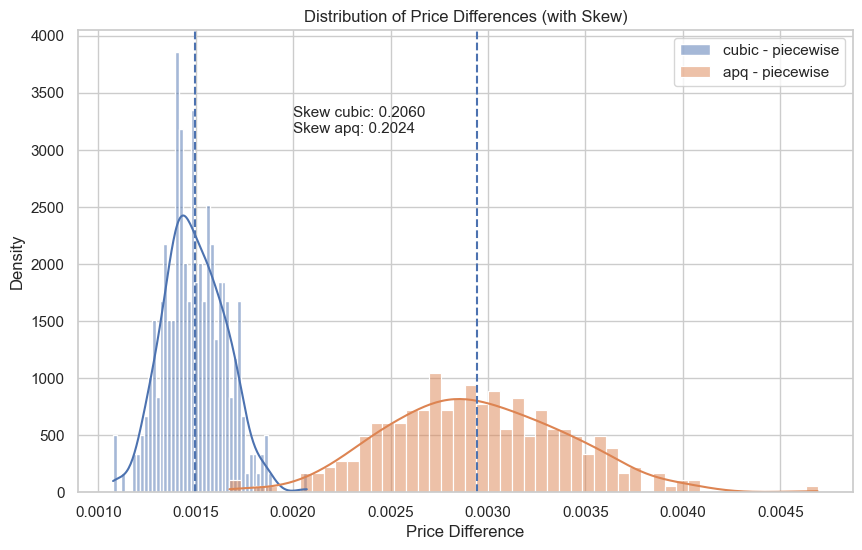

In [21]:
from scipy.stats import skew
import matplotlib.pyplot as plt
import seaborn as sns
skew_cubic = skew(diff_cubic)
skew_apq   = skew(diff_apq)

print("Skew (cubic - piecewise):", skew_cubic)
print("Skew (apq - piecewise):", skew_apq)

plt.figure(figsize=(10,6))

sns.histplot(diff_cubic, bins=50, kde=True, label='cubic - piecewise', stat='density', alpha=0.5)
sns.histplot(diff_apq, bins=50, kde=True, label='apq - piecewise', stat='density', alpha=0.5)

plt.axvline(diff_cubic.mean(), linestyle='--')
plt.axvline(diff_apq.mean(), linestyle='--')
plt.text(
    0.0020, 3150,
    f"Skew cubic: {skew_cubic:.4f}\nSkew apq: {skew_apq:.4f}",
    fontsize=11
)
plt.title("Distribution of Price Differences (with Skew)")
plt.xlabel("Price Difference")
plt.ylabel("Density")
plt.legend()
plt.show()
#Using Piecewise as a neutral comparison tool to find differences of cubic and aqp. 
#While both cubic and apq provide higher prices, APQ has higher price with larger dispersion while it is also more positively skewed indicating 
#more volatility in the price as well. On the other hand, APQ spline is smoother and less volatile while it is more assymetric then APQ. 